In [2]:
import pandas as pd

In [4]:
!pip install sqlalchemy psycopg2-binary pandas matplotlib

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.1 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 17.8 MB/s  0:00:00

   ---------------------------------------- 0/3 [psycopg2-binary]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   ----------------------

In [5]:
from sqlalchemy import create_engine, text

In [6]:
import matplotlib.pyplot as plt


In [7]:
from sqlalchemy import create_engine, text

usuario = "postgres"
password = "123456"
host = "localhost"
puerto = "5432"
base_datos = "datawarehouse_ventas"

engine = create_engine(
    f"postgresql+psycopg2://{usuario}:{password}@{host}:{puerto}/{base_datos}"
)

print("Conexión creada correctamente")

Conexión creada correctamente


In [8]:
with engine.connect() as conn:
    resultado = conn.execute(text("SELECT version();"))
    for fila in resultado:
        print(fila[0])

PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35226, 64-bit


In [9]:
clientes = pd.read_csv("dim_cliente.csv")
productos = pd.read_csv("dim_producto.csv")
regiones = pd.read_csv("dim_region.csv")
tiempo = pd.read_csv("dim_tiempo.csv")
ventas = pd.read_csv("fact_ventas.csv")

In [10]:
clientes.head()

,cliente_id,nombre_cliente,segmento
0,1,Ana López,Corporativo
1,2,Carlos Pérez,Minorista
2,3,María García,Corporativo
3,4,Juan Hernández,Corporativo
4,5,Lucía Martínez,Minorista


In [11]:
productos.head()

,producto_id,nombre_producto,categoria,precio_unitario
0,1,Laptop Lenovo,Computadoras,14500
1,2,Mouse Logitech,Accesorios,350
2,3,Teclado Mecánico,Accesorios,1200
3,4,Monitor Samsung,Monitores,4200
4,5,Impresora HP,Impresión,3100


In [12]:
regiones.head()

,region_id,region,estado
0,1,Norte,Nuevo León
1,2,Centro,CDMX
2,3,Sur,Chiapas
3,4,Occidente,Jalisco
4,5,Golfo,Veracruz


In [13]:
tiempo.head()

,tiempo_id,fecha,anio,mes,nombre_mes
0,1,2025-01-01,2025,1,Enero
1,2,2025-02-01,2025,2,Febrero
2,3,2025-03-01,2025,3,Marzo
3,4,2025-04-01,2025,4,Abril
4,5,2025-05-01,2025,5,Mayo


In [14]:
ventas.head()

,venta_id,cliente_id,producto_id,region_id,tiempo_id,cantidad,total_venta
0,1,1,9,1,1,3,2250
1,2,12,5,3,8,1,3100
2,3,12,6,1,3,3,5400
3,4,17,4,5,12,4,16800
4,5,10,10,2,10,2,1360


In [15]:
print("Valores nulos en clientes:")
print(clientes.isnull().sum())

print("\nValores nulos en productos:")
print(productos.isnull().sum())

print("\nValores nulos en regiones:")
print(regiones.isnull().sum())

print("\nValores nulos en tiempo:")
print(tiempo.isnull().sum())

print("\nValores nulos en ventas:")
print(ventas.isnull().sum())

Valores nulos en clientes:
cliente_id        0
nombre_cliente    0
segmento          0
dtype: int64

Valores nulos en productos:
producto_id        0
nombre_producto    0
categoria          0
precio_unitario    0
dtype: int64

Valores nulos en regiones:
region_id    0
region       0
estado       0
dtype: int64

Valores nulos en tiempo:
tiempo_id     0
fecha         0
anio          0
mes           0
nombre_mes    0
dtype: int64

Valores nulos en ventas:
venta_id       0
cliente_id     0
producto_id    0
region_id      0
tiempo_id      0
cantidad       0
total_venta    0
dtype: int64


In [16]:
clientes.to_sql("dim_cliente", engine, if_exists="append", index=False)
productos.to_sql("dim_producto", engine, if_exists="append", index=False)
regiones.to_sql("dim_region", engine, if_exists="append", index=False)
tiempo.to_sql("dim_tiempo", engine, if_exists="append", index=False)
ventas.to_sql("fact_ventas", engine, if_exists="append", index=False)

print("Datos cargados correctamente al Data Warehouse")

Datos cargados correctamente al Data Warehouse


In [17]:
consulta = """
SELECT COUNT(*) AS total_clientes
FROM dim_cliente;
"""

pd.read_sql(consulta, engine)

,total_clientes
0,20


In [18]:
consulta = """
SELECT COUNT(*) AS total_productos
FROM dim_producto;
"""

pd.read_sql(consulta, engine)

,total_productos
0,10


In [19]:
consulta = """
SELECT COUNT(*) AS total_regiones
FROM dim_region;
"""

pd.read_sql(consulta, engine)

,total_regiones
0,5


In [20]:
consulta = """
SELECT COUNT(*) AS total_fechas
FROM dim_tiempo;
"""

pd.read_sql(consulta, engine)

,total_fechas
0,12


In [21]:
consulta = """
SELECT COUNT(*) AS total_ventas
FROM fact_ventas;
"""

pd.read_sql(consulta, engine)


,total_ventas
0,120


In [22]:
consulta_general = """
SELECT 
    f.venta_id,
    c.nombre_cliente,
    c.segmento,
    p.nombre_producto,
    p.categoria,
    r.region,
    r.estado,
    t.nombre_mes,
    t.anio,
    f.cantidad,
    f.total_venta
FROM fact_ventas f
INNER JOIN dim_cliente c
    ON f.cliente_id = c.cliente_id
INNER JOIN dim_producto p
    ON f.producto_id = p.producto_id
INNER JOIN dim_region r
    ON f.region_id = r.region_id
INNER JOIN dim_tiempo t
    ON f.tiempo_id = t.tiempo_id
ORDER BY f.venta_id
LIMIT 20;
"""

reporte_general = pd.read_sql(consulta_general, engine)
reporte_general

,venta_id,nombre_cliente,segmento,nombre_producto,categoria,region,estado,nombre_mes,anio,cantidad,total_venta
0,1,Ana López,Corporativo,Router TP-Link,Redes,Norte,Nuevo León,Enero,2025,3,2250.0
1,2,Jorge Morales,Corporativo,Impresora HP,Impresión,Sur,Chiapas,Agosto,2025,1,3100.0
2,3,Jorge Morales,Corporativo,Disco SSD 1TB,Almacenamiento,Norte,Nuevo León,Marzo,2025,3,5400.0
3,4,Camila Ortega,Mayorista,Monitor Samsung,Monitores,Golfo,Veracruz,Diciembre,2025,4,16800.0
4,5,Luis Gómez,Corporativo,Webcam Full HD,Accesorios,Centro,CDMX,Octubre,2025,2,1360.0
5,6,Ricardo Reyes,Minorista,Memoria USB 64GB,Almacenamiento,Centro,CDMX,Julio,2025,1,180.0
6,7,Daniela Cruz,Mayorista,Router TP-Link,Redes,Centro,CDMX,Octubre,2025,7,5250.0
7,8,Daniela Cruz,Mayorista,Memoria USB 64GB,Almacenamiento,Sur,Chiapas,Mayo,2025,7,1260.0
8,9,Andrea Mendoza,Mayorista,Laptop Lenovo,Computadoras,Golfo,Veracruz,Octubre,2025,6,87000.0
9,10,Jorge Morales,Corporativo,Laptop Lenovo,Computadoras,Norte,Nuevo León,Mayo,2025,5,72500.0


In [23]:
consulta_ventas_region = """
SELECT 
    r.region,
    r.estado,
    SUM(f.total_venta) AS total_ventas
FROM fact_ventas f
INNER JOIN dim_region r
    ON f.region_id = r.region_id
GROUP BY r.region, r.estado
ORDER BY total_ventas DESC;
"""

ventas_region = pd.read_sql(consulta_ventas_region, engine)
ventas_region

,region,estado,total_ventas
0,Golfo,Veracruz,488450.0
1,Occidente,Jalisco,435520.0
2,Sur,Chiapas,366290.0
3,Centro,CDMX,259460.0
4,Norte,Nuevo León,257120.0


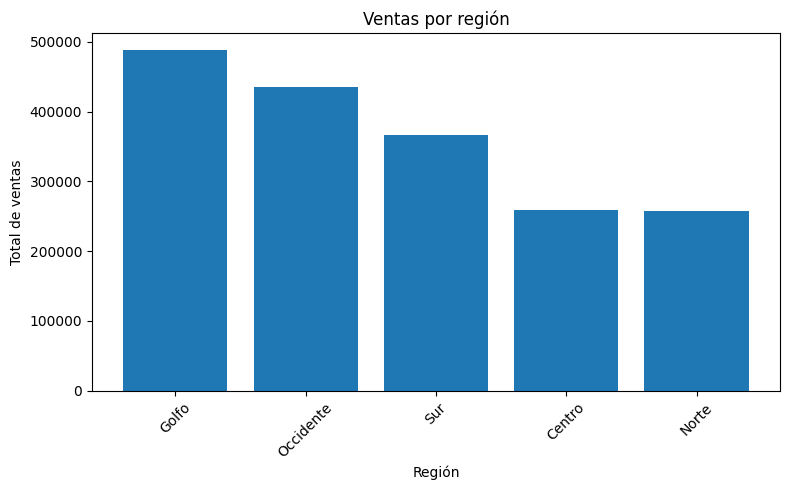

In [24]:
plt.figure(figsize=(8,5))
plt.bar(ventas_region["region"], ventas_region["total_ventas"])
plt.title("Ventas por región")
plt.xlabel("Región")
plt.ylabel("Total de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
consulta_productos = """
SELECT 
    p.nombre_producto,
    p.categoria,
    SUM(f.cantidad) AS productos_vendidos,
    SUM(f.total_venta) AS total_ventas
FROM fact_ventas f
INNER JOIN dim_producto p
    ON f.producto_id = p.producto_id
GROUP BY p.nombre_producto, p.categoria
ORDER BY productos_vendidos DESC;
"""

productos_vendidos = pd.read_sql(consulta_productos, engine)
productos_vendidos

,nombre_producto,categoria,productos_vendidos,total_ventas
0,Laptop Lenovo,Computadoras,80,1160000.0
1,Monitor Samsung,Monitores,69,289800.0
2,Teclado Mecánico,Accesorios,54,64800.0
3,Disco SSD 1TB,Almacenamiento,53,95400.0
4,Router TP-Link,Redes,50,37500.0
5,Audífonos Sony,Audio,50,47500.0
6,Memoria USB 64GB,Almacenamiento,44,7920.0
7,Webcam Full HD,Accesorios,29,19720.0
8,Mouse Logitech,Accesorios,28,9800.0
9,Impresora HP,Impresión,24,74400.0


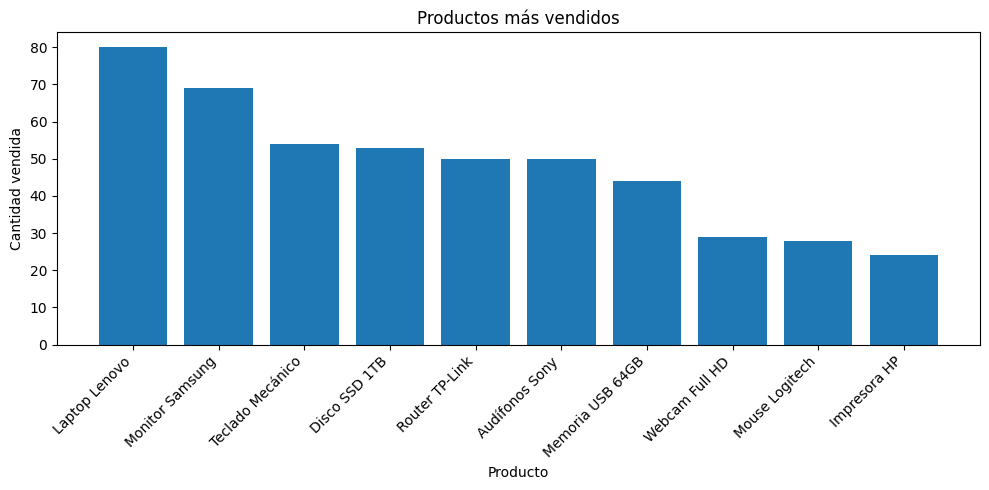

In [26]:
top_productos = productos_vendidos.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_productos["nombre_producto"], top_productos["productos_vendidos"])
plt.title("Productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad vendida")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [27]:
consulta_ventas_mes = """
SELECT 
    t.mes,
    t.nombre_mes,
    SUM(f.total_venta) AS total_ventas
FROM fact_ventas f
INNER JOIN dim_tiempo t
    ON f.tiempo_id = t.tiempo_id
GROUP BY t.mes, t.nombre_mes
ORDER BY t.mes;
"""

ventas_mes = pd.read_sql(consulta_ventas_mes, engine)
ventas_mes

,mes,nombre_mes,total_ventas
0,1,Enero,256260.0
1,2,Febrero,68200.0
2,3,Marzo,60100.0
3,4,Abril,64480.0
4,5,Mayo,402110.0
5,6,Junio,9800.0
6,7,Julio,118580.0
7,8,Agosto,213150.0
8,9,Septiembre,83500.0
9,10,Octubre,242820.0


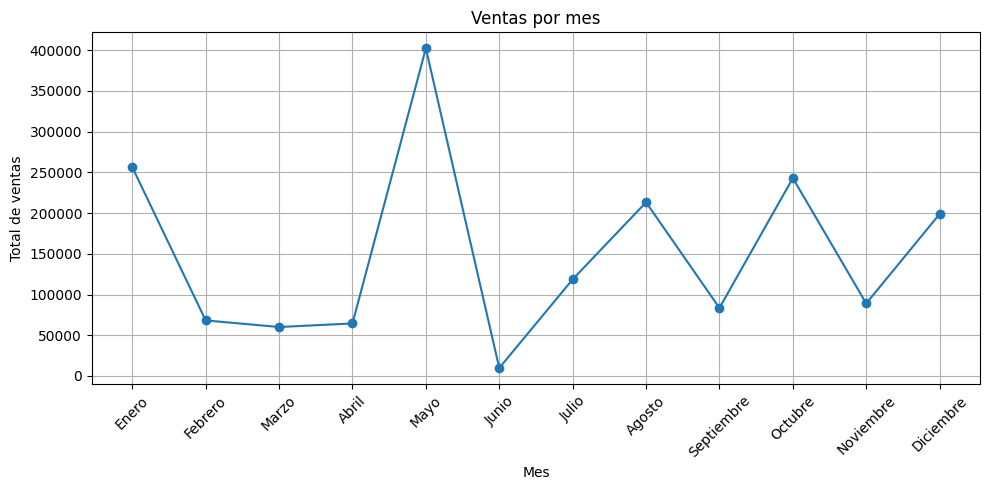

In [28]:
plt.figure(figsize=(10,5))
plt.plot(ventas_mes["nombre_mes"], ventas_mes["total_ventas"], marker="o")
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Total de ventas")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

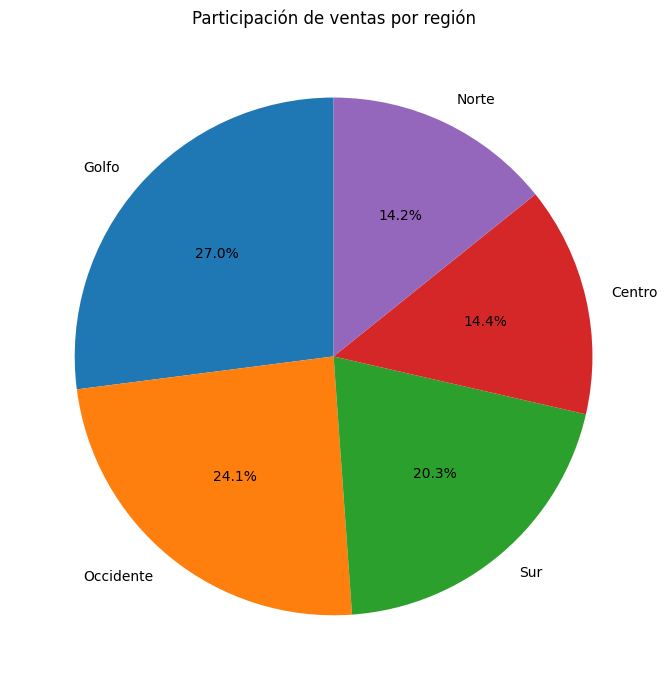

In [29]:
plt.figure(figsize=(7,7))
plt.pie(
    ventas_region["total_ventas"],
    labels=ventas_region["region"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Participación de ventas por región")
plt.tight_layout()
plt.show()

In [30]:
consulta_resumen = """
SELECT 
    COUNT(*) AS total_registros,
    SUM(cantidad) AS productos_vendidos,
    SUM(total_venta) AS ingresos_totales
FROM fact_ventas;
"""

resumen = pd.read_sql(consulta_resumen, engine)
resumen

,total_registros,productos_vendidos,ingresos_totales
0,120,481,1806840.0
